# Testing stuff
Here I am testing python modules and data processing techniques, to get familiar with tools.

In [1]:
import torch
from nevergrad.benchmark.experiments import simple_tsp

torch.manual_seed(69)

print("Testing concatenations....")
a = torch.randn(5,3)
b = torch.randn(5,3)
print("A", a)
print("B", b)
print("Concatenated:", torch.cat((a, b), dim=1))

Testing concatenations....
A tensor([[-0.5259, -2.6043, -0.6448],
        [ 1.4356, -0.5796, -0.7254],
        [ 1.6112, -0.0703,  0.4757],
        [-0.3330, -0.0810, -1.2897],
        [-1.1969,  0.6707, -1.2555]])
B tensor([[-1.1164,  1.2523, -1.5541],
        [-1.4058, -0.3329, -0.2117],
        [-0.4752,  0.0606,  1.9731],
        [ 0.1399,  0.1372, -2.0599],
        [ 1.1843,  0.4051, -0.0157]])
Concatenated: tensor([[-0.5259, -2.6043, -0.6448, -1.1164,  1.2523, -1.5541],
        [ 1.4356, -0.5796, -0.7254, -1.4058, -0.3329, -0.2117],
        [ 1.6112, -0.0703,  0.4757, -0.4752,  0.0606,  1.9731],
        [-0.3330, -0.0810, -1.2897,  0.1399,  0.1372, -2.0599],
        [-1.1969,  0.6707, -1.2555,  1.1843,  0.4051, -0.0157]])


## Exploring candidate datasets for training

### IOTID20
Apparently, this dataset is imbalanced, gives mainly focus on mirai attacks. Benign traffic is a minority.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 625783 entries, 2019-07-25 03:25:53 to 2019-07-25 03:25:10
Data columns (total 81 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Src_Port           625783 non-null  int64  
 1   Dst_Port           625783 non-null  int64  
 2   Protocol           625783 non-null  int64  
 3   Flow_Duration      625783 non-null  int64  
 4   Tot_Fwd_Pkts       625783 non-null  int64  
 5   Tot_Bwd_Pkts       625783 non-null  int64  
 6   TotLen_Fwd_Pkts    625783 non-null  float64
 7   TotLen_Bwd_Pkts    625783 non-null  float64
 8   Fwd_Pkt_Len_Max    625783 non-null  float64
 9   Fwd_Pkt_Len_Min    625783 non-null  float64
 10  Fwd_Pkt_Len_Mean   625783 non-null  float64
 11  Fwd_Pkt_Len_Std    625783 non-null  float64
 12  Bwd_Pkt_Len_Max    625783 non-null  float64
 13  Bwd_Pkt_Len_Min    625783 non-null  float64
 14  Bwd_Pkt_Len_Mean   625783 non-null  float64
 15  Bwd_Pkt_Len_Std  

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Category,Sub_Cat
Timestamp,,,,,,,,,,,,,,,,,,,,,
2019-07-25 03:25:53,10000,10101,17,75,1,1,982.0,1430.0,982.0,982.0,...,0.0,0.0,0.0,0.0,75.00,0.000000,75.0,75.0,Mirai,Mirai-Ackflooding
2019-05-26 22:11:06,2179,554,6,5310,1,2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2655.00,2261.327486,4254.0,1056.0,DoS,DoS-Synflooding
2019-07-11 01:24:48,52727,9020,6,141,0,3,0.0,2806.0,0.0,0.0,...,0.0,0.0,0.0,0.0,70.50,0.707107,71.0,70.0,Scan,Scan Port OS
2019-09-04 03:58:17,52964,9020,6,151,0,2,0.0,2776.0,0.0,0.0,...,0.0,0.0,0.0,0.0,151.00,0.000000,151.0,151.0,Mirai,Mirai-Hostbruteforceg
2019-09-10 01:41:18,36763,1900,17,153,2,1,886.0,420.0,452.0,434.0,...,0.0,0.0,0.0,0.0,76.50,0.707107,77.0,76.0,Mirai,Mirai-Hostbruteforceg
2019-09-10 01:39:13,41980,443,6,157,2,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,78.50,6.363961,83.0,74.0,Mirai,Mirai-Hostbruteforceg
2019-07-25 03:21:01,60175,8899,17,139,20,1,640.0,32.0,32.0,32.0,...,0.0,0.0,0.0,0.0,6.95,1.669384,10.0,4.0,Mirai,Mirai-UDP Flooding
2019-07-11 01:52:37,41467,443,6,112,0,2,0.0,2896.0,0.0,0.0,...,0.0,0.0,0.0,0.0,112.00,0.000000,112.0,112.0,Scan,Scan Port OS
2019-07-25 03:21:13,60132,8899,17,86,1,1,32.0,32.0,32.0,32.0,...,0.0,0.0,0.0,0.0,86.00,0.000000,86.0,86.0,Mirai,Mirai-UDP Flooding


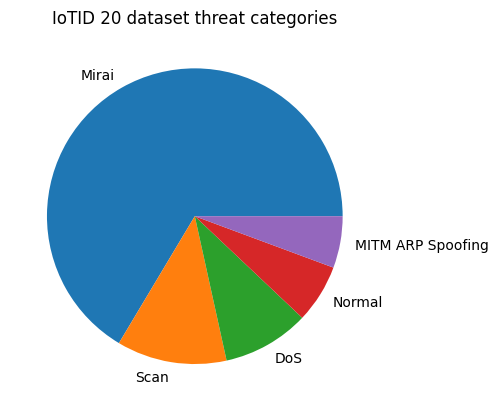

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/iotid20/iotid20.csv")
df = df.drop(columns=["Flow_ID", "Src_IP", "Dst_IP", "Label"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"],format="%d/%m/%Y %I:%M:%S %p")
df.set_index("Timestamp", inplace=True)
df.rename(columns={"Cat": "Category"}, inplace=True)
categories = df["Category"].value_counts()

def percent_formatter(x):
    return "{}\n({:.1f})%".format(int(categories.sum()*x/100) ,x)

plt.pie(categories.values, labels=categories.index)
plt.title("IoTID 20 dataset threat categories")
df.info(verbose=True)
print(df.columns.to_list())
head_data = df.head(10)
del df
head_data

### IoT-23

This is a large dataset. Split up to multiple csvs according to attack vector. A large portion of data are benign traffic. Contains the following attack types:
- Command and Control
- DDoS
- Malicious file downloads
- Mirai
- Okiru
- Port scan
- Heartbeat
- Torii

In [4]:
import pandas as pd

df = pd.read_csv("../datasets/IoT-23/attacks/DDoS[1].csv")
df = df.drop(columns=["Flow_ID", "Src_IP", "Dst_IP", "Label"], errors="ignore")
df["Timestamp"] = pd.to_datetime(df["Timestamp"],format="%d/%m/%Y %I:%M:%S %p")
df.set_index("Timestamp", inplace=True)
df.rename(columns={"Cat": "Category"}, inplace=True)
df.shape[1]
df.info()
head_data = df.head(10)
del df 
head_data

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5393746 entries, 2018-07-20 17:44:44 to 2018-09-06 15:05:19
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Src_Port           int64  
 1   Dst_Port           int64  
 2   Protocol           int64  
 3   Flow_Duration      int64  
 4   Tot_Fwd_Pkts       int64  
 5   Tot_Bwd_Pkts       int64  
 6   TotLen_Fwd_Pkts    float64
 7   TotLen_Bwd_Pkts    float64
 8   Fwd_Pkt_Len_Max    float64
 9   Fwd_Pkt_Len_Min    float64
 10  Fwd_Pkt_Len_Mean   float64
 11  Fwd_Pkt_Len_Std    float64
 12  Bwd_Pkt_Len_Max    float64
 13  Bwd_Pkt_Len_Min    float64
 14  Bwd_Pkt_Len_Mean   float64
 15  Bwd_Pkt_Len_Std    float64
 16  Flow_Byts/s        float64
 17  Flow_Pkts/s        float64
 18  Flow_IAT_Mean      float64
 19  Flow_IAT_Std       float64
 20  Flow_IAT_Max       float64
 21  Flow_IAT_Min       float64
 22  Fwd_IAT_Tot        float64
 23  Fwd_IAT_Mean       float64
 24  Bwd_IAT_Mean     

,Src_Port,Dst_Port,Protocol,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,...,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Sub_Cat
Timestamp,,,,,,,,,,,,,,,,,,,,,
2018-07-20 17:44:44,2074,80,17,1678539,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,DDoS
2018-07-20 17:44:11,8356,80,17,34506819,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,3.450682e+07,0.000000e+00,3.450682e+07,3.450682e+07,DDoS
2018-07-20 17:44:23,49635,80,17,3757355,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,DDoS
2018-07-20 17:44:24,41458,80,17,26676285,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,2.667628e+07,0.000000e+00,2.667628e+07,2.667628e+07,DDoS
2018-07-20 17:44:23,41910,80,17,9054086,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,0.000000e+00,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:35,4391,80,17,15388975,4,0,2048.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,6.697604e+06,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:21,54802,80,17,25820274,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,7.660620e+14,1.083370e+15,1.532120e+15,6.854589e+06,DDoS
2018-07-20 17:44:17,14609,80,17,11944688,3,0,1536.0,0.0,512.0,512.0,...,8,0,0,0,0,1.532120e+15,0.000000e+00,1.532120e+15,1.532120e+15,DDoS
2018-07-20 17:44:37,33252,80,17,11001973,2,0,1024.0,0.0,512.0,512.0,...,8,0,0,0,0,1.100197e+07,0.000000e+00,1.100197e+07,1.100197e+07,DDoS


### IDS-2018

This is a realistic environment dataset, covering a large range of cyber attacks

15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15997164 entries, 0 to 15997163
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   Timestamp  object
 1   Label      object
dtypes: object(2)
memory usage: 244.1+ MB
Label
Benign                      13248929
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64


,Timestamp,Label
0,21/02/2018 08:33:25,Benign
1,21/02/2018 08:33:06,Benign
2,21/02/2018 08:33:06,Benign
3,21/02/2018 08:33:11,Benign
4,21/02/2018 08:33:11,Benign
...,...,...
15997159,02/03/2018 02:08:18,Benign
15997160,02/03/2018 02:08:22,Benign
15997161,02/03/2018 02:08:25,Benign
15997162,02/03/2018 02:08:29,Benign


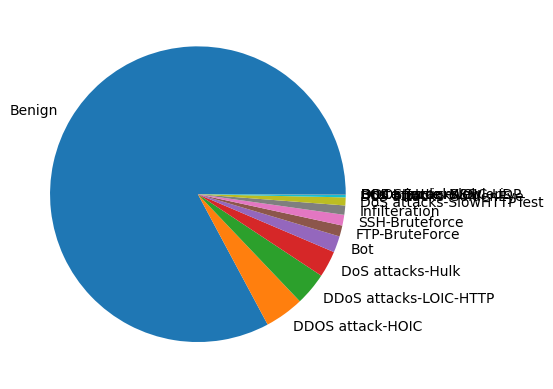

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/ids-2018/ids-2018-merged.csv", usecols=["Timestamp","Label"])
categories = df["Label"].value_counts()
print(categories.shape[0])
df.info()
print(categories)
plt.pie(categories.values, labels=categories.index)
df

In [ ]:
import pandas as pd

df = pd.read_csv("../datasets/ids-2018/ids-2018-merged.csv", nrows=5e+6)
df = df.drop(columns=["Src IP", "Dst IP", "Timestamp", "Label"])
df.info()
df

[ 0  4  3  1  2  9  8  6  5  7 10]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 83 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Src IP             int64  
 1   Src Port           int64  
 2   Dst IP             int64  
 3   Dst Port           int64  
 4   Protocol           int64  
 5   Timestamp          object 
 6   Flow Duration      int64  
 7   Tot Fwd Pkts       int64  
 8   Tot Bwd Pkts       int64  
 9   TotLen Fwd Pkts    int64  
 10  TotLen Bwd Pkts    int64  
 11  Fwd Pkt Len Max    int64  
 12  Fwd Pkt Len Min    int64  
 13  Fwd Pkt Len Mean   float64
 14  Fwd Pkt Len Std    float64
 15  Bwd Pkt Len Max    int64  
 16  Bwd Pkt Len Min    int64  
 17  Bwd Pkt Len Mean   float64
 18  Bwd Pkt Len Std    float64
 19  Flow Byts/s        float64
 20  Flow Pkts/s        float64
 21  Flow IAT Mean      float64
 22  Flow IAT Std       float64
 23  Flow IAT Max       int64  
 24  Flow IAT Min   

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,0,80,6,21/02/2018 08:33:25,37953,5,3,135,...,32,0.0,0.000,0,0,0.0,0.000000e+00,0,0,Benign
1,0,0,0,500,17,21/02/2018 08:33:06,117573474,3,0,1500,...,8,0.0,0.000,0,0,58800000.0,2.380000e+07,75600000,42000000,Benign
2,0,0,0,500,17,21/02/2018 08:33:06,117573474,3,0,1500,...,8,0.0,0.000,0,0,58800000.0,2.380000e+07,75600000,42000000,Benign
3,0,0,0,500,17,21/02/2018 08:33:11,99743998,5,0,2500,...,8,4000290.0,0.000,4000290,4000290,31900000.0,3.790000e+07,75600000,7200397,Benign
4,0,0,0,500,17,21/02/2018 08:33:11,99743999,5,0,2500,...,8,4000286.0,0.000,4000286,4000286,31900000.0,3.790000e+07,75600000,7200399,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,0,0,0,443,6,28/02/2018 02:51:21,5349532,8,6,353,...,20,287228.0,0.000,287228,287228,5062264.0,0.000000e+00,5062264,5062264,Benign
4999996,0,0,0,52799,6,28/02/2018 02:51:26,1,2,0,31,...,20,0.0,0.000,0,0,0.0,0.000000e+00,0,0,Benign
4999997,0,0,0,445,6,28/02/2018 02:51:27,7920660,2,0,0,...,20,0.0,0.000,0,0,0.0,0.000000e+00,0,0,Benign
4999998,0,0,0,443,6,28/02/2018 02:49:41,119929186,12,11,597,...,20,1542212.5,1773295.821,2796122,288303,58400000.0,5.052285e+05,58700000,58000000,Benign


## Embeddings

Experiments using embeddings. Embeddings are usually required when categorical data are present which affect output in non-linear way. With embeddings we enable models to learn more about each category

## Convolution and Pooling

Here convolution and pooling is tested, as its provided from PyTorch

In [21]:
import torch
import torch.nn as nn 

torch.manual_seed(42)
X = torch.randn(5,3)
print(X)
maxpool = nn.MaxPool1d(3, 1)
conv = nn.Conv1d(5, 3, 1)
relu = nn.ReLU()
print(relu(maxpool(X)))
print(conv(X))

tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617],
        [ 0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890]])
tensor([[0.3367],
        [0.2303],
        [2.2082],
        [0.8094],
        [1.1103]])
tensor([[ 0.0440,  0.1636,  0.2348],
        [-0.0539,  0.5779,  0.4548],
        [ 0.6880, -1.4024, -0.5970]], grad_fn=<SqueezeBackward1>)


In [26]:
import pandas as pd
import torch

df = pd.read_csv("../datasets/ddos-2019/cicddos2019_dataset.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print(df["Label"].astype("category").cat.codes.value_counts())
labels = df["Label"].astype("category")
print(labels.index[labels == "Benign"].to_numpy())

p = torch.tensor([[1,1],[2, float('nan')], [3, 1], [4,2]])
print(p[~p[:,1].isnan(), 1].mean().item())

p = torch.tensor([[1,1],[2, 0], [3, 1], [4,2]])
mode = p[:,1].mode().values.item()
p[p[:,1] == 0 , 1] = mode
print(p)

df.info()

4     121368
13     98917
0      97831
12     49373
14     18090
7      10420
15      8872
9       8523
3       6212
1       3669
6       2717
8       1906
2       1440
11       685
10       644
5        598
16        55
17        51
Name: count, dtype: int64
Benign
DrDoS_DNS
DrDoS_LDAP
DrDoS_MSSQL
DrDoS_NTP
DrDoS_NetBIOS
DrDoS_SNMP
DrDoS_UDP
LDAP
MSSQL
NetBIOS
Portmap
Syn
TFTP
UDP
UDP-lag
UDPLag
WebDDoS
[ 14937  14938  14939 ... 431368 431369 431370]
1.3333333730697632
tensor([[1, 1],
        [2, 1],
        [3, 1],
        [4, 2]])
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431371 entries, 0 to 431370
Data columns (total 79 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  431371 non-null  int64  
 1   Flow Duration             431371 non-null  int64  
 2   Total Fwd Packets         431371 non-null  int64  
 3   Total Backward Packets    431371 non-null  int64  
 4   Fwd Pack

## Processing LARGE CSVs

Dask to the rescue! Dask is a parallel processing python library which can process data fast in a very memory efficient way, unlike pandas. Can be installed via PIP:

`pip install dask[complete]`

And get the blocks of dataframe using to_delayed method. Dask can be integrated to pytorch using an iterable dataset. However iterable datasets do not support Subset of Pytorch, for Subset it must be mappable, that is override `__getitem__` instead:

```python
from torch.utils.data import IterableDataset

class DaskColumnDataset(IterableDataset):
    def __init__(self, ddf, column_name):
        self.ddf = ddf[column_name]

    def __iter__(self):
        # Iterate over partitions
        for part in self.ddf.to_delayed():
            # Each partition is computed separately
            col_np = part.compute().to_numpy()
            for val in col_np:
                yield torch.tensor(val)  # or yield val if already tensor-compatible

# Usage
ddf = dd.read_csv('your_file.csv')
dataset = DaskColumnDataset(ddf, 'your_column_name')
loader = torch.utils.data.DataLoader(dataset, batch_size=32)

for batch in loader:
    # Use batch in your training loop
    ...

```

In [8]:
import dask.dataframe
import numpy as np

ddf = dask.dataframe.read_csv("../datasets/IoT-23/IoT-23-merged.csv", blocksize="100M")
# Categorize
ddf = ddf.categorize(columns=["Sub Cat"])
ddf = ddf.replace([np.inf, -np.inf], np.nan)
np.set_printoptions(threshold=100)
# Compute the column first (as a Pandas Series), then access .cat.codes
codes_ddf = ddf.map_partitions(lambda df: df["Sub Cat"].cat.codes)
unique_codes = codes_ddf.unique().compute()
print(codes_ddf.nunique().compute())
# Step 2: Compute all means at once — returns a Pandas Series
col_means = ddf.mean(numeric_only=True, skipna=True).compute()
# Step 3: Fill NaNs in only those columns
for col, mean_val in col_means.items():
    if not np.isnan(mean_val):
        ddf[col] = ddf[col].fillna(mean_val)
print(unique_codes, len(unique_codes))
codes_array = codes_ddf.compute().to_numpy()
print(codes_array.shape)

10
0    4
0    3
0    1
0    7
0    0
0    6
0    2
0    5
0    9
0    8
dtype: int8 10
(37427467,)


## Plotting matrices

Useful for plotting confusion matrices. Can be achieved using `matplotlib` for plotting and `torcheval` for multiclass confusion matrix generation.

/tmp/ipykernel_430946/3851719224.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["", ""])
/tmp/ipykernel_430946/3851719224.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["",""])


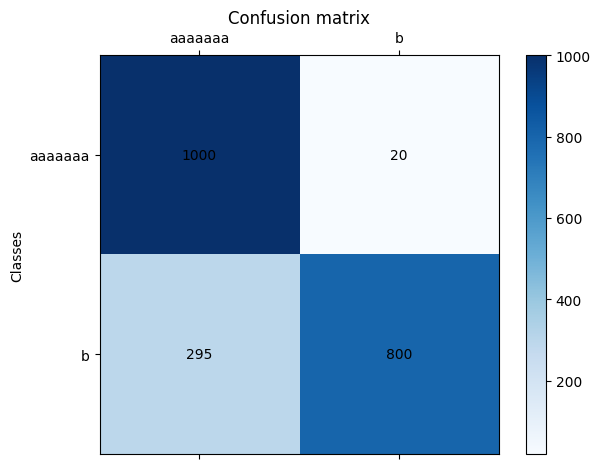

In [1]:
import matplotlib.pyplot as plt
import numpy as np

array = np.array([[1000, 20], [295, 800]])
fig, ax = plt.subplots()
ax.set_title("Confusion matrix")
ax.set_xticklabels(["", ""])
ax.set_yticklabels(["",""])
ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_ylabel("Classes")
ax.set_xticklabels(["aaaaaaa", "b"])
ax.set_yticklabels(["aaaaaaa", "b"])
mat = ax.matshow(array, cmap=plt.cm.Blues)
for i in range(2):
    for j in range(2):
        ax.text(j, i, array[i,j], ha="center", va="center")
plt.colorbar(mat)
fig.tight_layout()
plt.savefig("test.png", dpi=500)

In [2]:
import pandas as pd

#2017-SUEE dataset labeling

df = pd.read_csv("../datasets/2017-SUEE/SUEE8.pcap_Flow_original.csv")
malicious_flows = df[df["Src IP"].str.startswith("10.128")]
malicious_flows["Label"] = "Attack"


benign_flows = df[df["Src IP"].str.startswith("192.168")]
benign_flows["Label"] = "Benign"

malicious_flows.to_csv("../datasets/2017-SUEE/attack.csv")
benign_flows.to_csv("../datasets/2017-SUEE/normal.csv")

/tmp/ipykernel_430946/3189887719.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  malicious_flows["Label"] = "Attack"
/tmp/ipykernel_430946/3189887719.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  benign_flows["Label"] = "Benign"


KeyboardInterrupt: 

## Performance
Here you can find the performance of the 2 models under evaluation (transformer and LSTM). Models were tuned and trained with all dataset features, except Timestamp. The code below is a helper function to get dataframes stats with ease and is reusable.

In [59]:
import pandas as pd
import os
from IPython.display import display

def get_performance_stats(results_path):
    stats_df_list = []
    df_list = []
    metrics = ["F1 Score", "Accuracy", "Precision", "Recall"]
    for (root, _, files) in os.walk(results_path):
        for file in files:
            filename = os.path.join(root, file)
            df = pd.read_csv(filename, sep=",")
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            df_list.append(df)
            stats_df = pd.DataFrame(columns=["Attack", "Normal"])
            stats_df["Attack"] = df.loc[df["Class"] == "Attack"][metrics].mean()
            stats_df["Normal"] = df.loc[df["Class"] == "Normal"][metrics].mean()
            stats_df = stats_df.T
            stats_df["Dataset"] = file.split(".")[0]
            stats_df_list.append(stats_df)
    stats_per_dataset_df = pd.concat(stats_df_list, axis=0)
    del stats_df_list
    merged_df = pd.concat(df_list, axis=0)
    overall_performance_df = pd.DataFrame(columns=["Attack", "Normal"])
    overall_performance_df["Attack"] = merged_df.loc[merged_df["Class"] == "Attack"][metrics].mean()
    overall_performance_df["Normal"] = merged_df.loc[merged_df["Class"] == "Normal"][metrics].mean()
    return stats_per_dataset_df, overall_performance_df

### Transformer

In [60]:
stats_per_dataset, overall_stats = get_performance_stats("results/reports/transformer")
print("Performance per dataset:")
display(stats_per_dataset_df)
print("Overall performance:")
display(overall_performance_df.T)

Performance per dataset:


,F1 Score,Accuracy,Precision,Recall,Dataset
Attack,0.801679,0.731416,0.889219,0.731416,results_transformer_iotid20-binclass
Normal,0.834074,0.907524,0.772467,0.907524,results_transformer_iotid20-binclass
Attack,0.961694,0.940978,0.983428,0.940978,results_transformer_IoT-23-binclass
Normal,0.963381,0.984140,0.943540,0.984140,results_transformer_IoT-23-binclass
Attack,0.936935,0.897391,0.986926,0.897391,results_transformer_usfc-tfc-2016-binclass
Normal,0.934492,0.978791,0.896649,0.978791,results_transformer_usfc-tfc-2016-binclass
Attack,0.904415,0.840754,0.978528,0.840754,results_transformer_IoT-DS2-binclass
Normal,0.916998,0.981547,0.860424,0.981547,results_transformer_IoT-DS2-binclass
Attack,0.941048,0.929865,0.952588,0.929865,results_transformer_ids-2018-binclass
Normal,0.942458,0.953664,0.931584,0.953664,results_transformer_ids-2018-binclass


Overall performance:


,F1 Score,Accuracy,Precision,Recall
Attack,0.869052,0.823039,0.936831,0.823039
Normal,0.901779,0.958572,0.859302,0.958572


#### Feature importance per dataset

##### **IoT-DS2**

**Attack class:**
- Idle mean
- Src IP
- Dst IP
- Idle min
- Idle max

**Benign class:**
- Idle mean
- Idle std
- Idle max
- Flow duration
- Flow IAT std

##### **USFC-TFC-2016**
**Attack class:**
- Src IP
- Dst IP
- Float IAT max

**Benign class:**
- Src IP
- Dst IP

##### **IOTid20**
**Attack class:**
- Src IP
- Dst IP
- Flow byts/s

**Benign class:**
- Src IP
- Dst IP
- Flow byts/s

##### CIC-UNSW-NB15
**Attack class:**
- Src IP
- Dst IP

**Benign class:**
- Src IP
- Dst IP

##### MQTT-IoT-IDS2020
**Attack class:**
- Idle mean
- Idle min
- Idle max
- Idle std
- Src IP
- Dst IP

**Benign class:**

Same as attack class:
- Idle mean
- Idle min
- Idle max
- Idle std
- Src IP
- Dst IP

##### IDS-2018
**Attack class:**
- Src IP
- Dst IP
- Fwd pkts/s
- Fwd IAT std
- Init Fwd Win Byts
- Bwd pkts/s
- Fwd IAT max
- Flow IAT max

**Benign class:**
- Src IP
- Dst IP
- Fwd IAT Tot
- Pkt len var
- Flow duration
- Bwd IAT std
- Init Fwd Win Byts

##### IoT-23
**Attack class:**
- Idle mean
- Idle min
- Dst IP
- Idle max
- Fwd pkts/s
- Flow pkts/s

**Benign class:**
- Idle min
- Idle mean
- Dst IP
- Idle max
- Fwd pkts/s
- Flow pkts/s


### LSTM


In [61]:
stats_per_dataset, overall_stats = get_performance_stats("results/reports/lstm")
print("Performance per dataset:")
display(stats_per_dataset)
print("Overall performance:")
display(overall_stats.T)

Performance per dataset:


,F1 Score,Accuracy,Precision,Recall,Dataset
Attack,0.996536,0.994406,0.998767,0.994406,results_lstm_IoT-23-binclass
Normal,0.996636,0.998768,0.994597,0.998768,results_lstm_IoT-23-binclass
Attack,0.955398,0.953382,0.994114,0.953382,results_lstm_usfc-tfc-2016-binclass
Normal,0.979806,0.993731,0.972597,0.993731,results_lstm_usfc-tfc-2016-binclass
Attack,0.986055,0.981654,0.994299,0.981654,results_lstm_IoT-DS2-binclass
Normal,0.988933,0.994302,0.984729,0.994302,results_lstm_IoT-DS2-binclass
Attack,0.961258,0.946763,0.976325,0.946763,results_lstm_ids-2018-binclass
Normal,0.962361,0.976876,0.948371,0.976876,results_lstm_ids-2018-binclass
Attack,0.967243,0.972950,0.963111,0.972950,results_lstm_CIC-UNSW-NB15-binclass
Normal,0.966465,0.961093,0.973863,0.961093,results_lstm_CIC-UNSW-NB15-binclass


Overall performance:


,F1 Score,Accuracy,Precision,Recall
Attack,0.968998,0.960968,0.983509,0.960968
Normal,0.973358,0.983293,0.965257,0.983293


#### Feature importance per dataset

##### **IoT-DS2**

**Attack class:**
- Init fwd win byts
- Pkt len var
- Fwd seg size min
- Fwd IAT Min
- Flow IAT Min
- Bwd IAT Max
- Idle max
- Idle std
- Subflow bwd byts
- Init Bwd Win Byts
- Dst port
- Fwd header len

**Benign class:**
- Fwd seg size min
- Fwd header len
- Pkt size avg
- Pkt len var
- Init fwd win byts
- Init bwd win byts
- Bwd pkts/s
- Fwd pkts/s

##### **USFC-TFC-2016**
**Attack class:**
- Fwd seg size min
- Flow IAT max
- Flow IAT std
- Flow duration
- Bwd IAT max
- Fwd act data pkts

**Benign class:**
- Fwd seg size min
- Flow duration
- Flow IAT mean
- Flow IAT min
- Fwd IAT min
- Dst port
- Fwd act data pkts

##### **IOTid20**
**Attack class:**
- Init bwd win byts
- Subflow fwd byts
- Idle mean
- Idle std
- Idle max
- Idle min

**Benign class:**
- Init bwd win byts
- Idle mean
- Subflow fwd byts
- Idle std

##### **CIC-UNSW-NB15**
**Attack class:**
- Fwd seg size min
- Fwd act data pkts
- Flow IAT mean

**Benign class:**
- Fwd seg size min

##### **MQTT-IoT-IDS2020**
**Attack class:**
- Init bwd win byts
- Init fwd win byts
- Bwd blk rate avg
- Subflow fwd byts
- Fwd seg size avg

**Benign class:**
- Init bwd win byts
- Init fwd win byts
- Bwd blk rate avg
- Subflow fwd byts

##### **IDS-2018**
**Attack class:**
- Fwd IAT Max
- Bwd seg size avg
- Totlen bwd byts
- Dst port
- Bwd pkts/s
- Init bwd win byts
- Flow IAT min
- Pkt len var
- Fwd IAT min

**Benign class:**
- Subflow fwd byts
- Bwd seg size avg
- Init fwd win byts
- Pkt len var

##### **IoT-23**
**Attack class:**
- Fwd seg size min
- Fwd header len
- Fwd pkts/s

**Benign class:**
- Fwd seg size min
- Fwd header len
- Flow IAT mean
